# 02 - Exploratory Data Analysis (EDA)

- Compute descriptive statistics to understand the dataset's structure and basic characteristics.
- Analyze distributions of key variables, relationships between features, and potential anomalies.
- Visualize patterns and trends using charts, histograms, correlation maps, and other relevant plots.

**Input:** `data/processed/transactions_parquet` (cleaned output of notebook 01)  
**Dataset:** ~1.3 M credit card transactions, Jan 2019 - Dec 2020  

## 1. Setup & Data Loading

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import math
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

cwd = Path.cwd()
project_root = cwd if (cwd / 'src').exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from src.pipeline import create_spark_session

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FRAUD_PALETTE = {0: '#4C9BE8', 1: '#E84C4C'}
FIG_DIR = project_root / 'notebooks' / 'eda_figures'
FIG_DIR.mkdir(exist_ok=True)

spark = create_spark_session(app_name='CreditCardEDA')
input_parquet = project_root / 'data' / 'processed' / 'transactions_parquet'
df = spark.read.parquet(str(input_parquet))
print(f'Loaded {df.count():,} rows  |  {len(df.columns)} columns')
print(f'Figures saved to: {FIG_DIR}')

26/04/28 09:00:11 WARN Utils: Your hostname, elaf resolves to a loopback address: 127.0.1.1; using 10.62.40.16 instead (on interface wlp1s0)
26/04/28 09:00:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 09:00:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded 1,296,675 rows  |  23 columns
Figures saved to: /home/elaf/Desktop/big-data-analytics-credit-card-transactions/notebooks/eda_figures


## 2. Dataset Overview

In [2]:
print('=== Schema ===')
df.printSchema()

=== Schema ===
root
 |-- transaction_id: string (nullable = true)
 |-- transaction_ts: timestamp (nullable = true)
 |-- card_id: string (nullable = true)
 |-- merchant: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- category: string (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- city_pop: long (nullable = true)
 |-- job: string (nullable = true)
 |-- dob: string (nullable = true)
 |-- unix_time: long (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- merch_zipcode: string (nullable = true)



In [3]:
print('=== Sample rows ===')
df.select('transaction_id', 'transaction_ts', 'amount', 'category', 'gender',
          'city', 'state', 'is_fraud').show(10, truncate=False)

=== Sample rows ===
+--------------------------------+-------------------+------+-------------+------+-----------+-----+--------+
|transaction_id                  |transaction_ts     |amount|category     |gender|city       |state|is_fraud|
+--------------------------------+-------------------+------+-------------+------+-----------+-----+--------+
|000163efab01b5ed89ad0b3025fd2dc6|2019-05-13 14:36:18|59.33 |home         |F     |Jones      |AL   |0       |
|0001d73e875fc1db9646c7c9d12e6470|2019-04-06 18:43:09|39.33 |kids_pets    |M     |Oakland    |CA   |0       |
|00025a7a8b21f957dd49beae5e151cee|2019-07-06 22:27:40|16.48 |home         |F     |Sturgis    |MS   |0       |
|00053542fc6d27a9e06e05d677921a47|2020-05-03 16:42:33|49.7  |kids_pets    |M     |Mc Intosh  |SD   |0       |
|0006f300016e04d3be88d19123c1f39c|2019-04-28 15:25:02|34.59 |kids_pets    |M     |Allentown  |NY   |0       |
|0007a9036ea25a6ac909f851b8cd1afc|2019-08-11 01:02:22|4.11  |shopping_net |M     |Hatch      |UT   |

In [4]:
print('=== Null counts per column ===')
null_counts = df.select([
    F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns
]).toPandas().T.rename(columns={0: 'null_count'})
null_counts['null_pct'] = (null_counts['null_count'] / df.count() * 100).round(2)
print(null_counts[null_counts['null_count'] > 0].to_string())
print(f'\nColumns with no nulls: {(null_counts["null_count"] == 0).sum()}')

=== Null counts per column ===


               null_count  null_pct
merch_zipcode      195973     15.11

Columns with no nulls: 22


In [5]:
date_range = df.agg(
    F.min('transaction_ts').alias('earliest'),
    F.max('transaction_ts').alias('latest')
).collect()[0]
print(f'Date range: {date_range["earliest"]}  →  {date_range["latest"]}')

card_count  = df.select('card_id').distinct().count()
merch_count = df.select('merchant').distinct().count()
state_count = df.select('state').distinct().count()
cat_count   = df.select('category').distinct().count()
print(f'Unique cards       : {card_count:,}')
print(f'Unique merchants   : {merch_count:,}')
print(f'Unique states      : {state_count}')
print(f'Unique categories  : {cat_count}')

Date range: 2019-01-01 03:00:18  →  2020-06-21 15:13:37
Unique cards       : 983
Unique merchants   : 693
Unique states      : 51
Unique categories  : 14


26/04/28 09:00:26 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## 3. Descriptive Statistics

In [6]:
numeric_cols = ['amount', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']
print('=== Numeric descriptive statistics ===')
df.select(numeric_cols).describe().show(truncate=False)

=== Numeric descriptive statistics ===


26/04/28 09:00:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+-----------------+------------------+-----------------+------------------+------------------+
|summary|amount            |lat              |long              |city_pop         |merch_lat         |merch_long        |
+-------+------------------+-----------------+------------------+-----------------+------------------+------------------+
|count  |1296675           |1296675          |1296675           |1296675          |1296675           |1296675           |
|mean   |70.35103545607039 |38.53762161490121|-90.22633537864226|88824.44056297839|38.53733804469969 |-90.22646479897296|
|stddev |160.31603857152743|5.075808438803931|13.759076946486331|301956.3606887511|5.1097883696791735|13.771090564792429|
|min    |1.0               |20.0271          |-165.6723         |23               |19.027785         |-166.671242       |
|max    |28948.9           |66.6933          |-67.9503          |2906700          |67.510267         |-66.950902        |
+-------+---------------

In [7]:
print('=== Transaction amount percentiles ===')
percentiles = df.select(
    F.percentile_approx('amount', [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).alias('pcts')
).collect()[0]['pcts']
labels = ['p1', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99']
for l, v in zip(labels, percentiles):
    print(f'  {l:>4}: ${v:>9.2f}')

=== Transaction amount percentiles ===


    p1: $     1.26
    p5: $     2.44
   p10: $     4.11
   p25: $     9.65
   p50: $    47.51
   p75: $    83.12
   p90: $   136.63
   p95: $   196.19
   p99: $   544.29


In [8]:
print('=== Class balance (is_fraud) ===')
fraud_dist = df.groupBy('is_fraud').count().orderBy('is_fraud').toPandas()
fraud_dist['pct'] = (fraud_dist['count'] / fraud_dist['count'].sum() * 100).round(3)
print(fraud_dist.to_string(index=False))

=== Class balance (is_fraud) ===
 is_fraud   count    pct
        0 1289169 99.421
        1    7506  0.579


In [9]:
print('=== Transactions per category ===')
cat_dist = df.groupBy('category').agg(
    F.count('*').alias('tx_count'),
    F.round(F.mean('amount'), 2).alias('avg_amount'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).orderBy(F.desc('tx_count')).toPandas()
print(cat_dist.to_string(index=False))

=== Transactions per category ===
      category  tx_count  avg_amount  fraud_rate_pct
 gas_transport    131659       63.43           0.469
   grocery_pos    123638      116.96           1.410
          home    123115       58.27           0.161
  shopping_pos    116672       79.78           0.723
     kids_pets    113035       57.54           0.211
  shopping_net     97543       88.42           1.756
 entertainment     94014       64.21           0.248
   food_dining     91461       51.09           0.165
 personal_care     90758       47.97           0.242
health_fitness     85879       54.18           0.155
      misc_pos     79655       62.89           0.314
      misc_net     63287       80.87           1.446
   grocery_net     45452       53.67           0.295
        travel     40507      111.50           0.286


In [10]:
print('=== Gender distribution ===')
gender_dist = df.groupBy('gender').agg(
    F.count('*').alias('count'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).toPandas()
print(gender_dist.to_string(index=False))

=== Gender distribution ===
gender  count  fraud_rate_pct
     F 709863           0.526
     M 586812           0.643


In [11]:
print('=== Top 15 states by transaction volume ===')
state_dist = df.groupBy('state').agg(
    F.count('*').alias('tx_count'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).orderBy(F.desc('tx_count')).limit(15).toPandas()
print(state_dist.to_string(index=False))

=== Top 15 states by transaction volume ===
state  tx_count  fraud_rate_pct
   TX     94876           0.505
   NY     83501           0.665
   PA     79847           0.574
   CA     56360           0.578
   OH     46480           0.691
   MI     46154           0.516
   IL     43252           0.573
   FL     42671           0.659
   AL     40989           0.525
   MO     38403           0.497
   MN     31714           0.653
   AR     31127           0.517
   NC     30266           0.492
   WI     29368           0.555
   VA     29250           0.677


## 4. Data Distributions

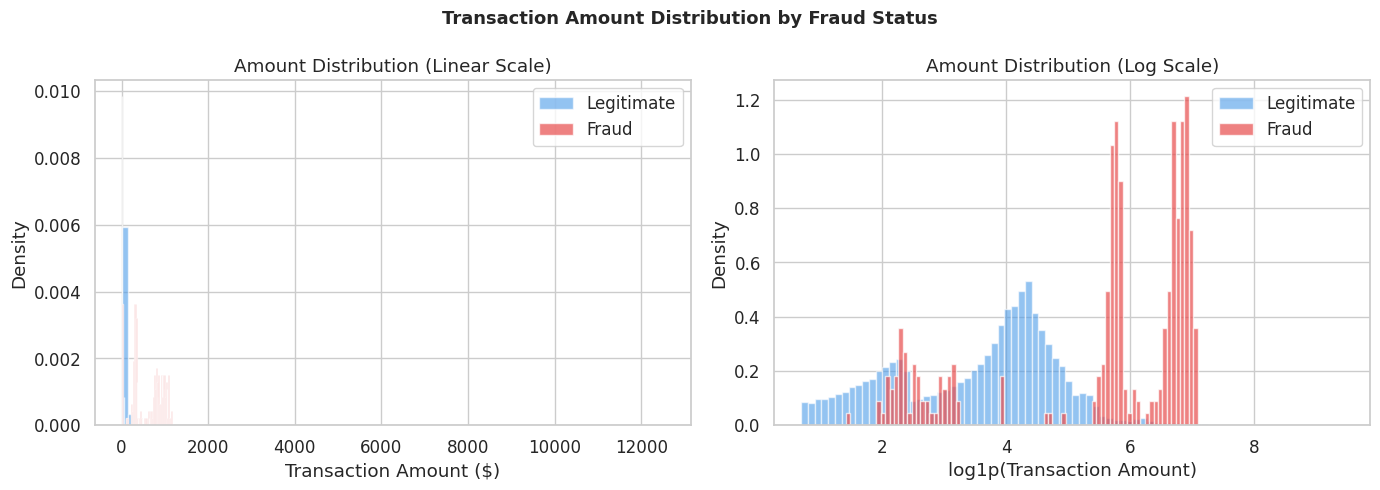

Saved: amount_distribution.png


In [12]:
# Sample 50k rows for local matplotlib plotting
sample_pd = df.select('amount', 'is_fraud', 'gender', 'category').sample(False, 0.04, seed=42).toPandas()
sample_pd['is_fraud_label'] = sample_pd['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(sample_pd[sample_pd['is_fraud'] == 0]['amount'], bins=80, alpha=0.6,
             color=FRAUD_PALETTE[0], label='Legitimate', density=True)
axes[0].hist(sample_pd[sample_pd['is_fraud'] == 1]['amount'], bins=80, alpha=0.7,
             color=FRAUD_PALETTE[1], label='Fraud', density=True)
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (Linear Scale)')
axes[0].legend()

# Log scale
axes[1].hist(sample_pd[sample_pd['is_fraud'] == 0]['amount'].apply(lambda x: math.log1p(x)),
             bins=80, alpha=0.6, color=FRAUD_PALETTE[0], label='Legitimate', density=True)
axes[1].hist(sample_pd[sample_pd['is_fraud'] == 1]['amount'].apply(lambda x: math.log1p(x)),
             bins=80, alpha=0.7, color=FRAUD_PALETTE[1], label='Fraud', density=True)
axes[1].set_xlabel('log1p(Transaction Amount)')
axes[1].set_ylabel('Density')
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].legend()

plt.suptitle('Transaction Amount Distribution by Fraud Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: amount_distribution.png')

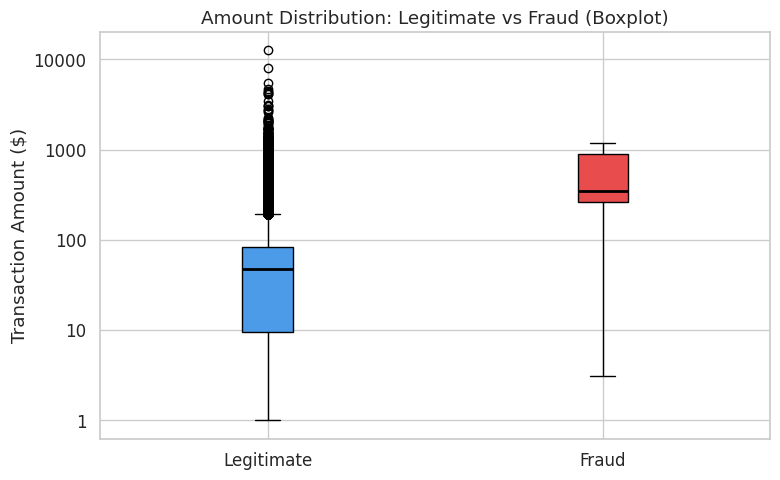

Saved: amount_boxplot.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
data_legit = sample_pd[sample_pd['is_fraud'] == 0]['amount']
data_fraud = sample_pd[sample_pd['is_fraud'] == 1]['amount']
bp = ax.boxplot([data_legit, data_fraud], labels=['Legitimate', 'Fraud'],
                patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(FRAUD_PALETTE[0])
bp['boxes'][1].set_facecolor(FRAUD_PALETTE[1])
ax.set_ylabel('Transaction Amount ($)')
ax.set_title('Amount Distribution: Legitimate vs Fraud (Boxplot)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.savefig(FIG_DIR / 'amount_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: amount_boxplot.png')

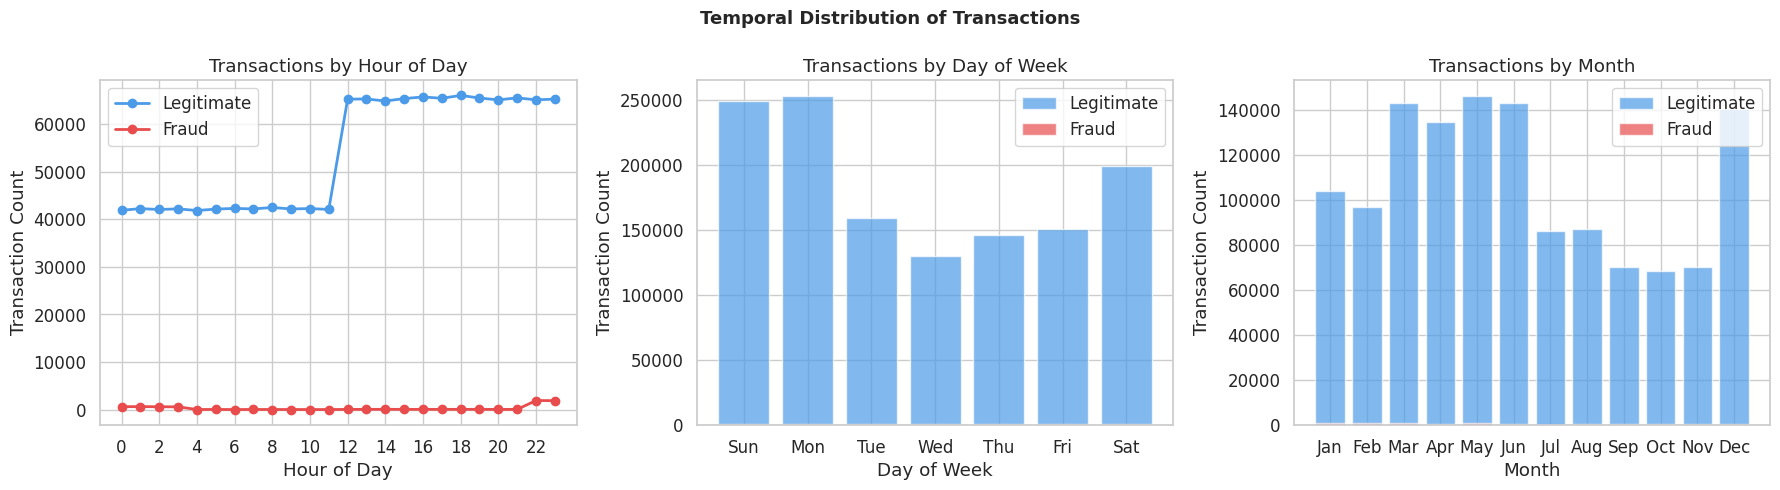

Saved: temporal_distributions.png


In [14]:
# Temporal distributions aggregated via Spark
temporal_pd = df.withColumn('tx_hour', F.hour('transaction_ts')) \
                .withColumn('tx_dow',  F.dayofweek('transaction_ts')) \
                .withColumn('tx_month', F.month('transaction_ts')) \
                .groupBy('tx_hour', 'tx_dow', 'tx_month', 'is_fraud') \
                .count().toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dow_labels = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# By hour
hour_g = temporal_pd.groupby(['tx_hour', 'is_fraud'])['count'].sum().reset_index()
for fraud_val, color in FRAUD_PALETTE.items():
    subset = hour_g[hour_g['is_fraud'] == fraud_val]
    label = 'Fraud' if fraud_val else 'Legitimate'
    axes[0].plot(subset['tx_hour'], subset['count'], marker='o', color=color, label=label, linewidth=2)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Transactions by Hour of Day')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# By day of week
dow_g = temporal_pd.groupby(['tx_dow', 'is_fraud'])['count'].sum().reset_index()
for fraud_val, color in FRAUD_PALETTE.items():
    subset = dow_g[dow_g['is_fraud'] == fraud_val].sort_values('tx_dow')
    label = 'Fraud' if fraud_val else 'Legitimate'
    axes[1].bar([dow_labels.get(d, d) for d in subset['tx_dow']],
                subset['count'], color=color, alpha=0.7, label=label)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Transactions by Day of Week')
axes[1].legend()

# By month
month_g = temporal_pd.groupby(['tx_month', 'is_fraud'])['count'].sum().reset_index()
for fraud_val, color in FRAUD_PALETTE.items():
    subset = month_g[month_g['is_fraud'] == fraud_val].sort_values('tx_month')
    label = 'Fraud' if fraud_val else 'Legitimate'
    axes[2].bar([month_labels.get(m, m) for m in subset['tx_month']],
                subset['count'], color=color, alpha=0.7, label=label)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Transaction Count')
axes[2].set_title('Transactions by Month')
axes[2].legend()

plt.suptitle('Temporal Distribution of Transactions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'temporal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: temporal_distributions.png')

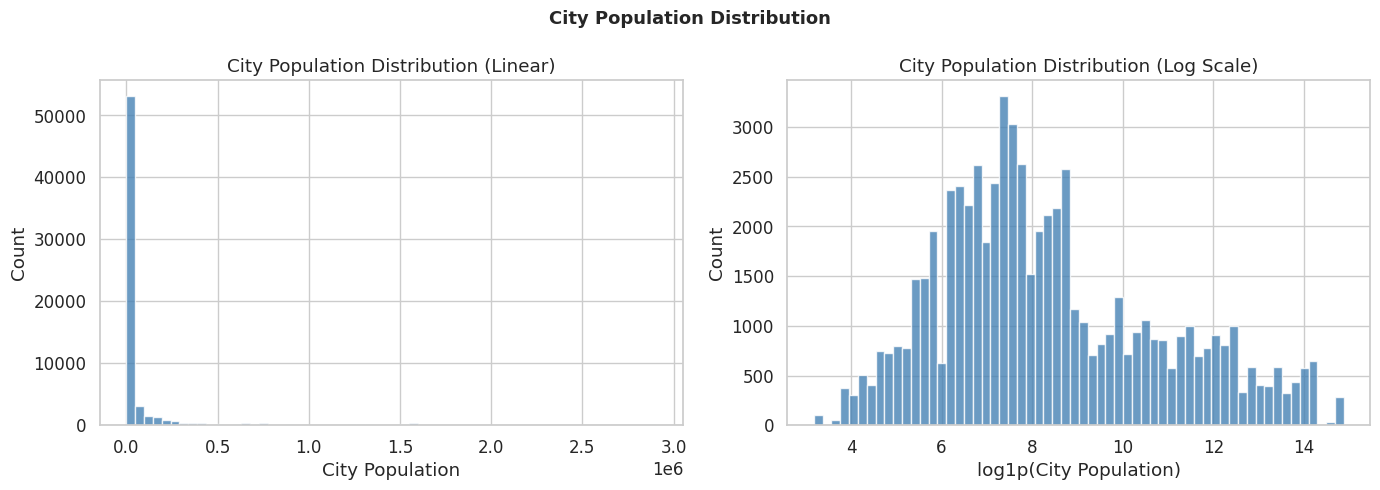

Saved: city_population_distribution.png


In [15]:
city_pop_pd = df.select('city_pop').sample(False, 0.05, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(city_pop_pd['city_pop'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('City Population')
axes[0].set_ylabel('Count')
axes[0].set_title('City Population Distribution (Linear)')

axes[1].hist(city_pop_pd['city_pop'].dropna().apply(lambda x: math.log1p(x)),
             bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log1p(City Population)')
axes[1].set_ylabel('Count')
axes[1].set_title('City Population Distribution (Log Scale)')

plt.suptitle('City Population Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'city_population_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: city_population_distribution.png')

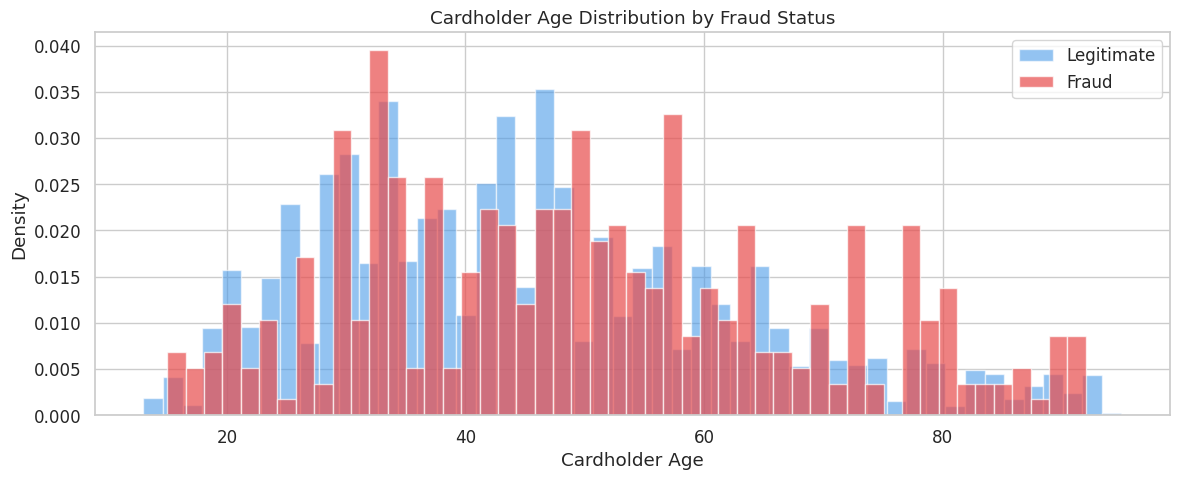

Saved: age_distribution.png


In [16]:
age_pd = df.withColumn('dob_ts', F.to_date(F.col('dob'), 'yyyy-MM-dd')) \
           .withColumn('age', F.floor(
               F.datediff(F.col('transaction_ts').cast('date'), F.col('dob_ts')) / 365.25
           )) \
           .select('age', 'is_fraud') \
           .sample(False, 0.05, seed=42) \
           .toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(age_pd[age_pd['is_fraud'] == 0]['age'].dropna(), bins=50,
        color=FRAUD_PALETTE[0], alpha=0.6, label='Legitimate', density=True)
ax.hist(age_pd[age_pd['is_fraud'] == 1]['age'].dropna(), bins=50,
        color=FRAUD_PALETTE[1], alpha=0.7, label='Fraud', density=True)
ax.set_xlabel('Cardholder Age')
ax.set_ylabel('Density')
ax.set_title('Cardholder Age Distribution by Fraud Status')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: age_distribution.png')

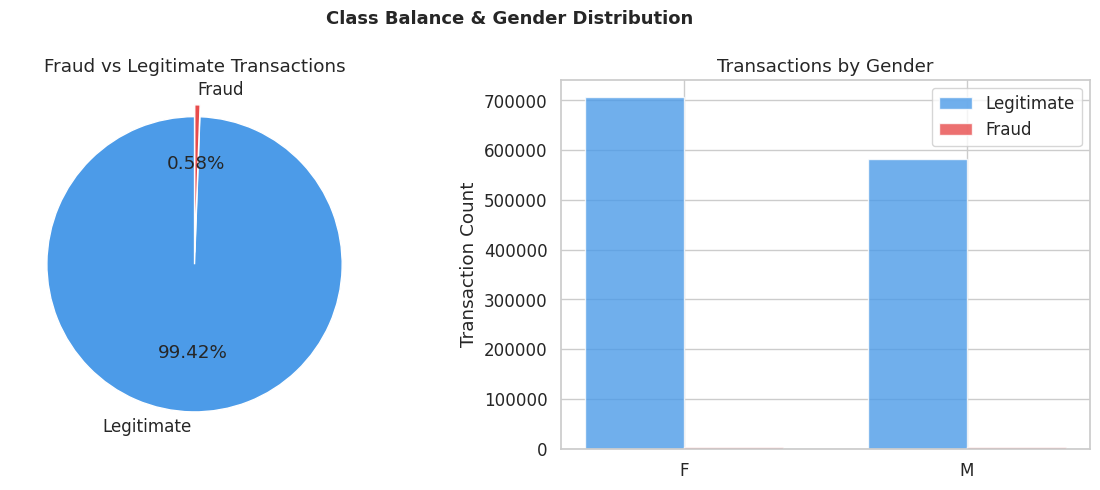

Saved: class_gender_distribution.png


In [17]:
fraud_counts = df.groupBy('is_fraud').count().orderBy('is_fraud').toPandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    fraud_counts['count'],
    labels=['Legitimate', 'Fraud'],
    colors=[FRAUD_PALETTE[0], FRAUD_PALETTE[1]],
    autopct='%1.2f%%',
    startangle=90,
    explode=[0, 0.08]
)
axes[0].set_title('Fraud vs Legitimate Transactions')

gender_fraud = df.groupBy('gender').agg(
    F.sum(F.when(F.col('is_fraud') == 0, 1).otherwise(0)).alias('legitimate'),
    F.sum(F.when(F.col('is_fraud') == 1, 1).otherwise(0)).alias('fraud')
).toPandas()
x = np.arange(len(gender_fraud))
width = 0.35
axes[1].bar(x - width/2, gender_fraud['legitimate'], width, label='Legitimate', color=FRAUD_PALETTE[0], alpha=0.8)
axes[1].bar(x + width/2, gender_fraud['fraud'],      width, label='Fraud',      color=FRAUD_PALETTE[1], alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(gender_fraud['gender'])
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('Transactions by Gender')
axes[1].legend()

plt.suptitle('Class Balance & Gender Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_gender_distribution.png')

## 5. Relationships & Correlations

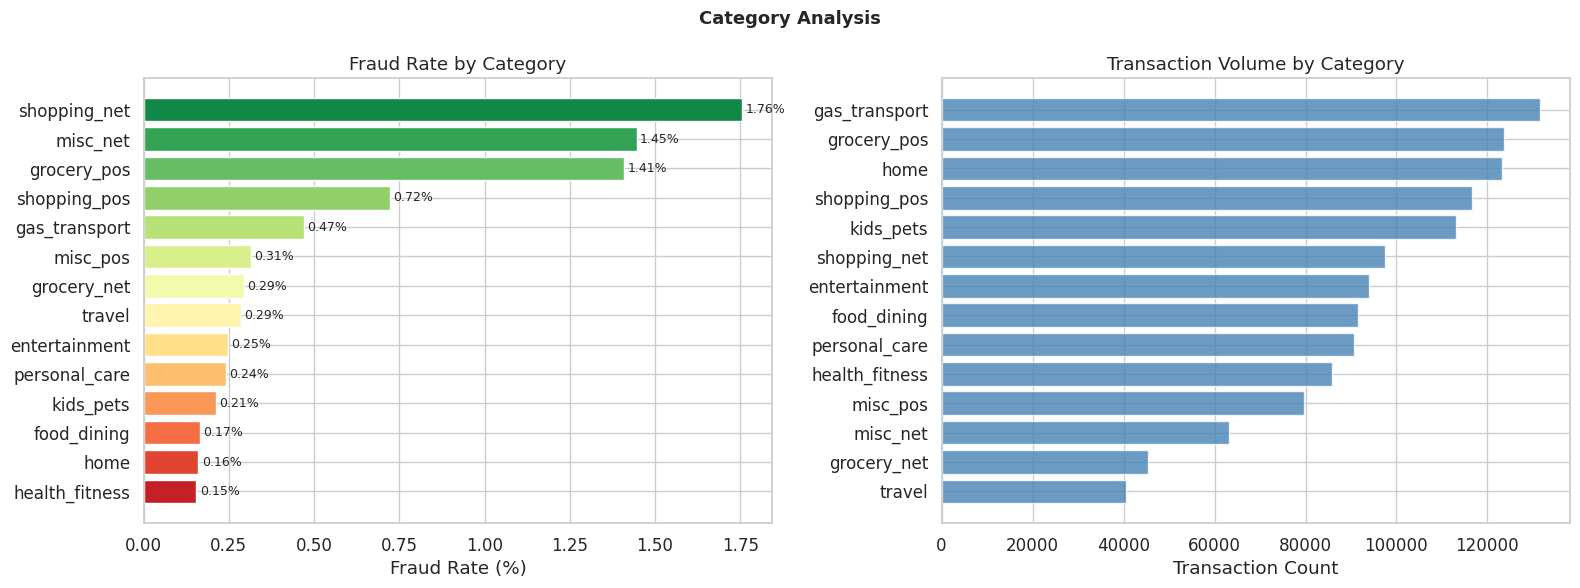

Saved: category_analysis.png


In [18]:
cat_fraud = df.groupBy('category').agg(
    F.count('*').alias('total'),
    F.sum('is_fraud').alias('fraud_count')
).withColumn('fraud_rate', F.round(F.col('fraud_count') / F.col('total') * 100, 3)) \
 .orderBy(F.desc('fraud_rate')).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by category
colors = sns.color_palette('RdYlGn_r', len(cat_fraud))
axes[0].barh(cat_fraud['category'], cat_fraud['fraud_rate'], color=colors)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Category')
axes[0].invert_yaxis()
for i, (val, label) in enumerate(zip(cat_fraud['fraud_rate'], cat_fraud['category'])):
    axes[0].text(val + 0.01, i, f'{val:.2f}%', va='center', fontsize=9)

# Transaction volume by category
cat_vol = cat_fraud.sort_values('total', ascending=True)
axes[1].barh(cat_vol['category'], cat_vol['total'], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Transaction Count')
axes[1].set_title('Transaction Volume by Category')

plt.suptitle('Category Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: category_analysis.png')

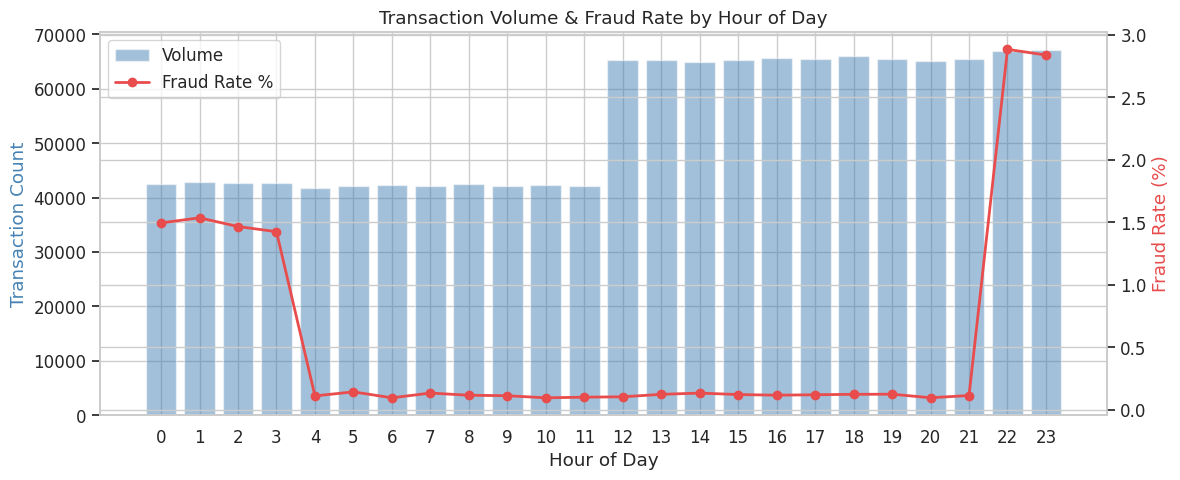

Saved: fraud_rate_by_hour.png


In [19]:
hour_fraud = df.withColumn('tx_hour', F.hour('transaction_ts')) \
               .groupBy('tx_hour').agg(
                   F.count('*').alias('total'),
                   F.sum('is_fraud').alias('fraud_count')
               ).withColumn('fraud_rate', F.col('fraud_count') / F.col('total') * 100) \
                .orderBy('tx_hour').toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(hour_fraud['tx_hour'], hour_fraud['total'], color='steelblue', alpha=0.5, label='Volume')
ax2.plot(hour_fraud['tx_hour'], hour_fraud['fraud_rate'], color=FRAUD_PALETTE[1],
         marker='o', linewidth=2, label='Fraud Rate %')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Transaction Count', color='steelblue')
ax2.set_ylabel('Fraud Rate (%)', color=FRAUD_PALETTE[1])
ax1.set_title('Transaction Volume & Fraud Rate by Hour of Day')
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fraud_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fraud_rate_by_hour.png')

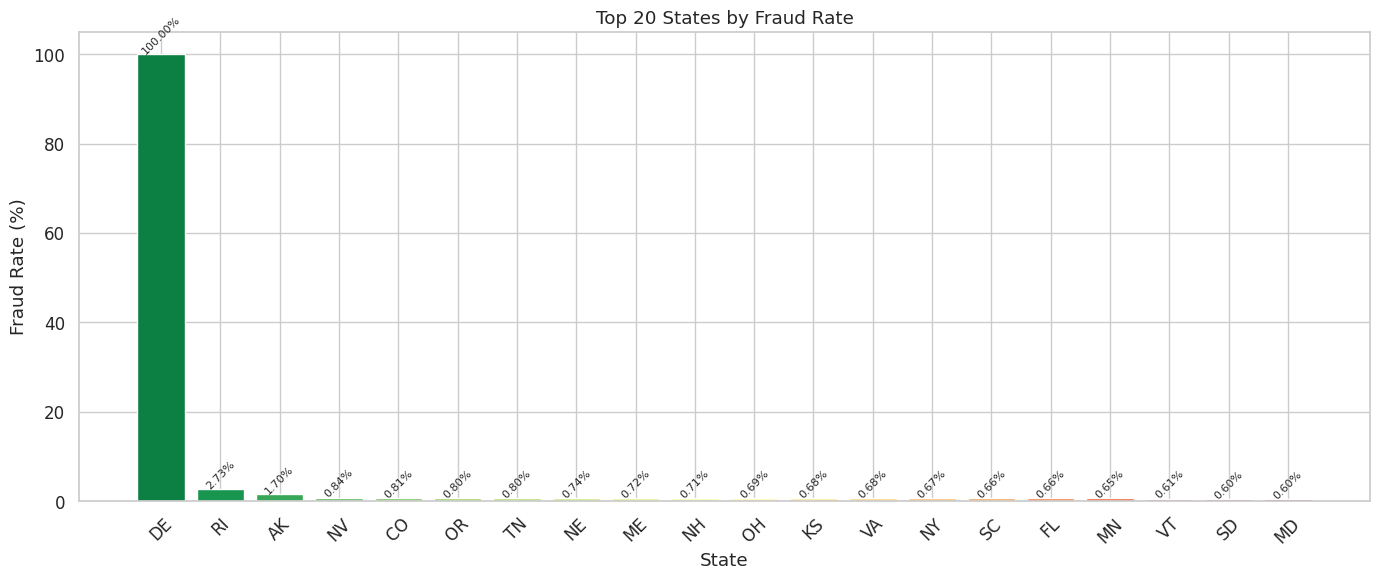

Saved: fraud_rate_by_state.png


In [20]:
state_fraud = df.groupBy('state').agg(
    F.count('*').alias('total'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate')
).orderBy(F.desc('fraud_rate')).limit(20).toPandas()

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('RdYlGn_r', len(state_fraud))
ax.bar(state_fraud['state'], state_fraud['fraud_rate'], color=palette)
ax.set_xlabel('State')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Top 20 States by Fraud Rate')
for i, val in enumerate(state_fraud['fraud_rate']):
    ax.text(i, val + 0.01, f'{val:.2f}%', ha='center', fontsize=8, rotation=45)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fraud_rate_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fraud_rate_by_state.png')

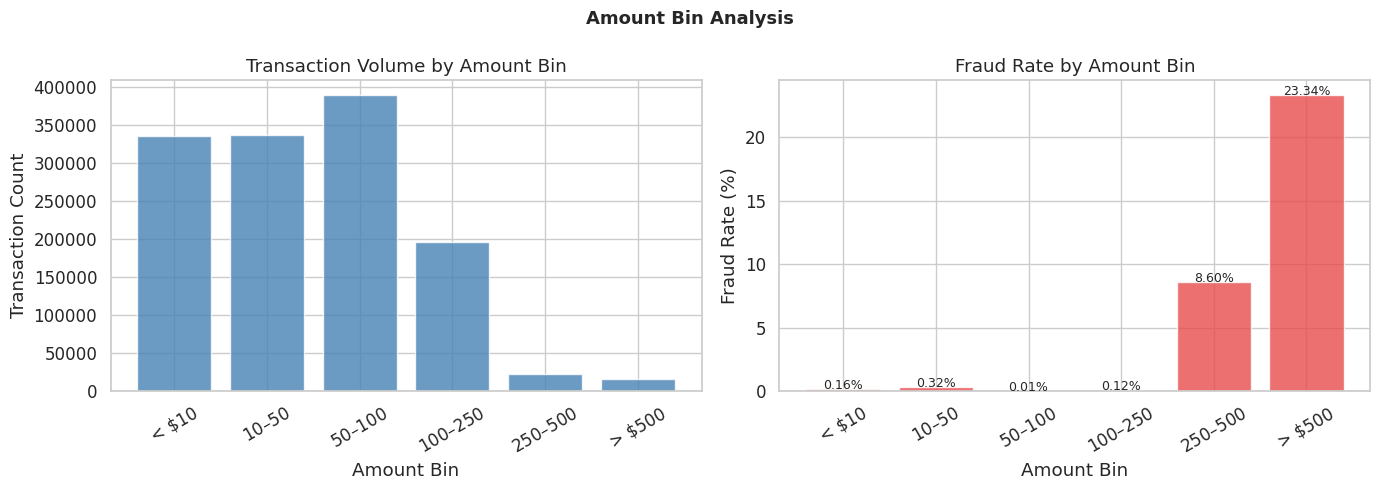

Saved: amount_bin_analysis.png


In [21]:
amount_bin_fraud = df.withColumn(
    'amount_bin',
    F.when(F.col('amount') < 10, '< $10')
     .when(F.col('amount') < 50, '$10–$50')
     .when(F.col('amount') < 100, '$50–$100')
     .when(F.col('amount') < 250, '$100–$250')
     .when(F.col('amount') < 500, '$250–$500')
     .otherwise('> $500')
).groupBy('amount_bin').agg(
    F.count('*').alias('total'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate')
).toPandas()

bin_order = ['< $10', '$10–$50', '$50–$100', '$100–$250', '$250–$500', '> $500']
amount_bin_fraud['amount_bin'] = pd.Categorical(amount_bin_fraud['amount_bin'],
                                                 categories=bin_order, ordered=True)
amount_bin_fraud = amount_bin_fraud.sort_values('amount_bin')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(amount_bin_fraud['amount_bin'], amount_bin_fraud['total'],
            color='steelblue', alpha=0.8)
axes[0].set_xlabel('Amount Bin')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Transaction Volume by Amount Bin')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(amount_bin_fraud['amount_bin'], amount_bin_fraud['fraud_rate'],
            color=FRAUD_PALETTE[1], alpha=0.8)
axes[1].set_xlabel('Amount Bin')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Amount Bin')
axes[1].tick_params(axis='x', rotation=30)
for i, val in enumerate(amount_bin_fraud['fraud_rate']):
    axes[1].text(i, val + 0.01, f'{val:.2f}%', ha='center', fontsize=9)

plt.suptitle('Amount Bin Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'amount_bin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: amount_bin_analysis.png')

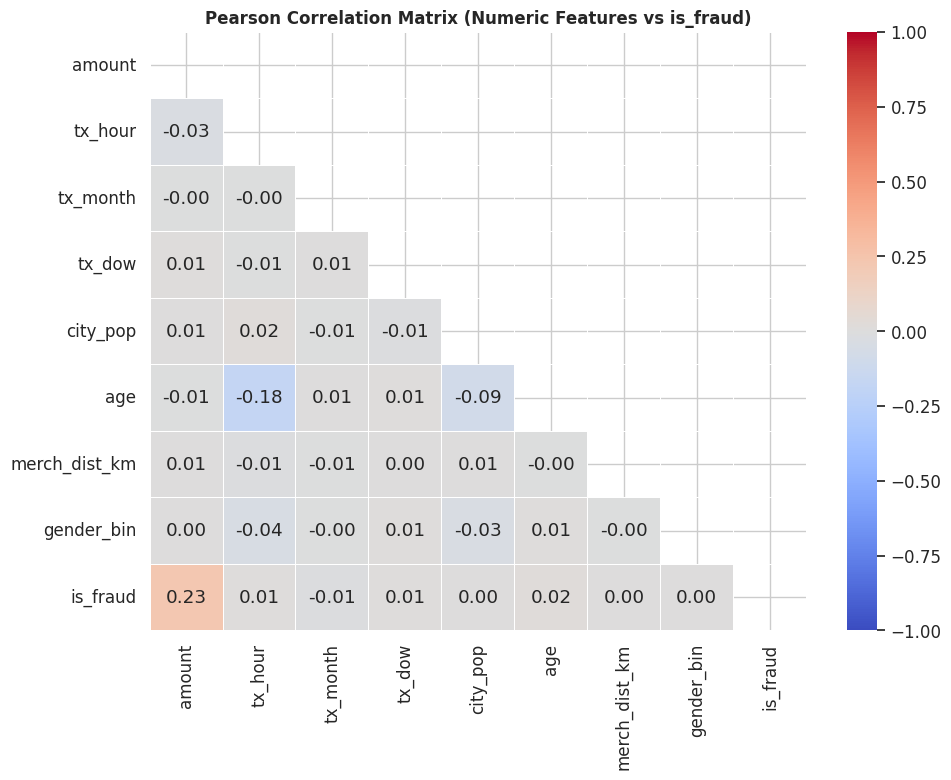

Saved: correlation_heatmap.png

Correlation with is_fraud (sorted):
amount           0.231119
age              0.022790
tx_dow           0.012441
tx_hour          0.008880
tx_month        -0.007880
city_pop         0.004050
merch_dist_km    0.003712
gender_bin       0.003166


In [22]:
# Compute age and distance in Spark, then bring a sample to pandas for correlation
@F.udf(returnType=DoubleType())
def haversine_km(lat1, lon1, lat2, lon2):
    if any(v is None for v in [lat1, lon1, lat2, lon2]):
        return None
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat/2)**2
         + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2)
    return R * 2 * math.asin(math.sqrt(a))

corr_df = df.withColumn('tx_hour',  F.hour('transaction_ts')) \
            .withColumn('tx_month', F.month('transaction_ts')) \
            .withColumn('tx_dow',   F.dayofweek('transaction_ts')) \
            .withColumn('age', F.floor(
                F.datediff(
                    F.col('transaction_ts').cast('date'),
                    F.to_date(F.col('dob'), 'yyyy-MM-dd')
                ) / 365.25
            )) \
            .withColumn('merch_dist_km',
                        haversine_km('lat', 'long', 'merch_lat', 'merch_long')) \
            .withColumn('gender_bin', F.when(F.upper(F.col('gender')) == 'M', 1).otherwise(0))

numeric_for_corr = ['amount', 'tx_hour', 'tx_month', 'tx_dow',
                    'city_pop', 'age', 'merch_dist_km', 'gender_bin', 'is_fraud']

corr_sample = corr_df.select(numeric_for_corr).sample(False, 0.03, seed=42).toPandas()
corr_sample = corr_sample.dropna()

corr_matrix = corr_sample.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Pearson Correlation Matrix (Numeric Features vs is_fraud)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

print('\nCorrelation with is_fraud (sorted):')
print(corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False).to_string())

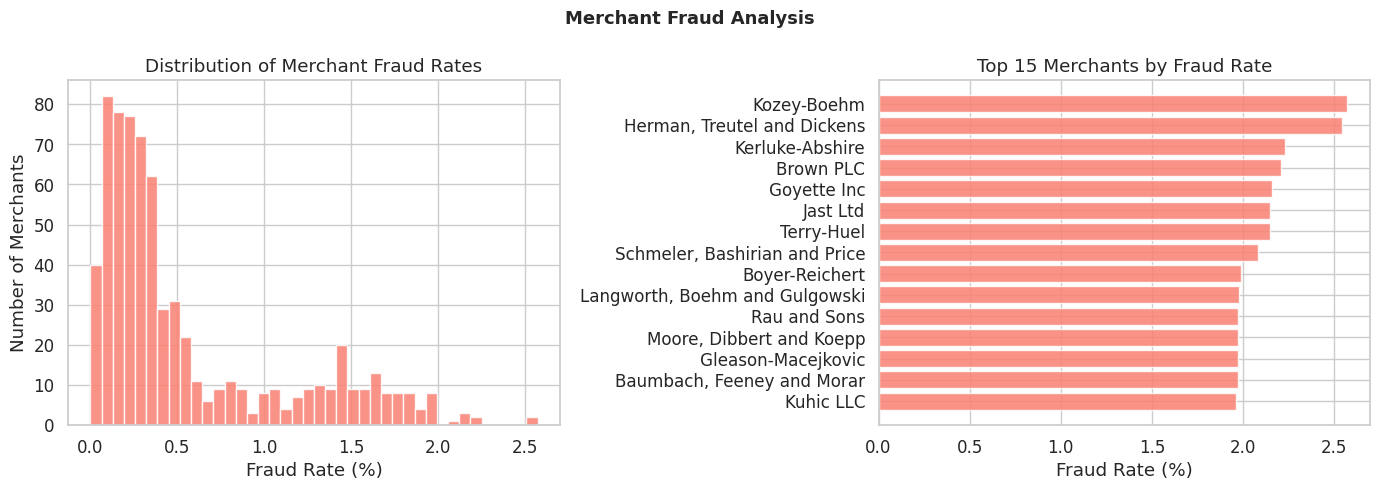

Saved: merchant_fraud_analysis.png


In [23]:
merch_stats = df.groupBy('merchant').agg(
    F.count('*').alias('tx_count'),
    F.sum('is_fraud').alias('fraud_count'),
    F.round(F.mean('is_fraud') * 100, 2).alias('fraud_rate')
).filter(F.col('tx_count') >= 20).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(merch_stats['fraud_rate'], bins=40, color='salmon', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_ylabel('Number of Merchants')
axes[0].set_title('Distribution of Merchant Fraud Rates')

top_fraud_merch = merch_stats.nlargest(15, 'fraud_rate')
axes[1].barh(top_fraud_merch['merchant'].str.replace('fraud_', '', regex=False),
             top_fraud_merch['fraud_rate'], color='salmon', alpha=0.85)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_title('Top 15 Merchants by Fraud Rate')
axes[1].invert_yaxis()

plt.suptitle('Merchant Fraud Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'merchant_fraud_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: merchant_fraud_analysis.png')

## 6. Geographic Patterns

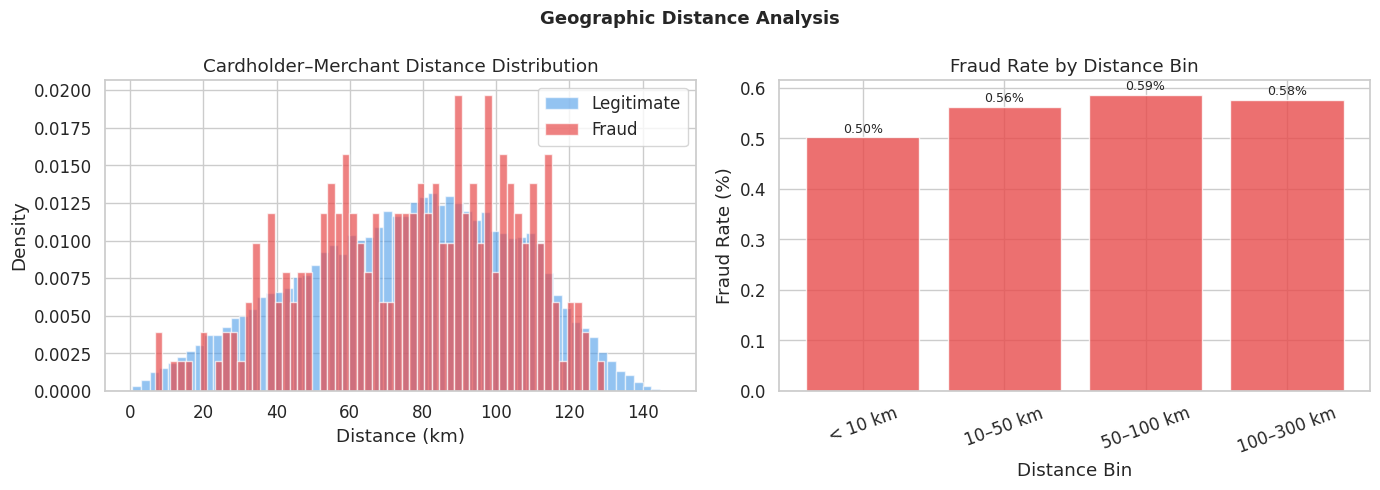

Saved: geo_distance_analysis.png


In [27]:
# Distribution of merchant-to-cardholder distances
dist_pd = corr_df.select('merch_dist_km', 'is_fraud') \
                 .filter(F.col('merch_dist_km').isNotNull()) \
                 .sample(False, 0.03, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dist_pd[dist_pd['is_fraud'] == 0]['merch_dist_km'], bins=60,
             color=FRAUD_PALETTE[0], alpha=0.6, label='Legitimate', density=True)
axes[0].hist(dist_pd[dist_pd['is_fraud'] == 1]['merch_dist_km'], bins=60,
             color=FRAUD_PALETTE[1], alpha=0.7, label='Fraud', density=True)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Density')
axes[0].set_title('Cardholder–Merchant Distance Distribution')
axes[0].legend()

dist_bins = df.withColumn('merch_dist_km',
                haversine_km('lat', 'long', 'merch_lat', 'merch_long')) \
             .withColumn('dist_bin',
                F.when(F.col('merch_dist_km') < 10,   '< 10 km')
                 .when(F.col('merch_dist_km') < 50,   '10–50 km')
                 .when(F.col('merch_dist_km') < 100,  '50–100 km')
                 .when(F.col('merch_dist_km') < 300,  '100–300 km')
                 .otherwise('> 300 km')
             ).groupBy('dist_bin').agg(
                 F.count('*').alias('total'),
                 F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate')
             ).toPandas()

bin_order_d = ['< 10 km', '10–50 km', '50–100 km', '100–300 km', '> 300 km']
dist_bins['dist_bin'] = pd.Categorical(dist_bins['dist_bin'], categories=bin_order_d, ordered=True)
dist_bins = dist_bins.sort_values('dist_bin')
axes[1].bar(dist_bins['dist_bin'], dist_bins['fraud_rate'], color=FRAUD_PALETTE[1], alpha=0.8)
axes[1].set_xlabel('Distance Bin')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Distance Bin')
for i, val in enumerate(dist_bins['fraud_rate']):
    axes[1].text(i, val + 0.01, f'{val:.2f}%', ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Geographic Distance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'geo_distance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: geo_distance_analysis.png')

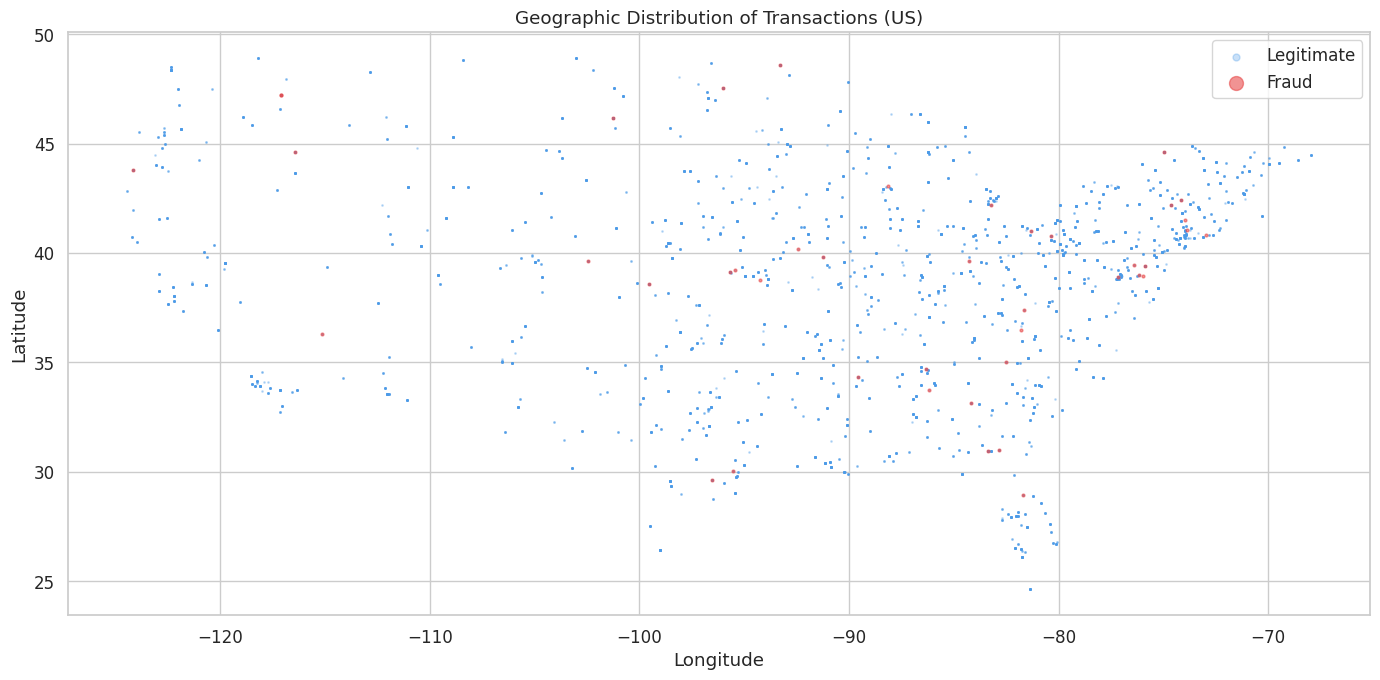

Saved: geo_scatter.png


In [28]:
# Scatter plot: cardholder locations colored by fraud
geo_sample = df.select('lat', 'long', 'is_fraud') \
               .filter(F.col('lat').between(24, 50) & F.col('long').between(-130, -60)) \
               .sample(False, 0.005, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(14, 7))
legit = geo_sample[geo_sample['is_fraud'] == 0]
fraud = geo_sample[geo_sample['is_fraud'] == 1]
ax.scatter(legit['long'], legit['lat'], s=1, c=FRAUD_PALETTE[0], alpha=0.3, label='Legitimate')
ax.scatter(fraud['long'], fraud['lat'], s=4, c=FRAUD_PALETTE[1], alpha=0.6, label='Fraud')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of Transactions (US)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'geo_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: geo_scatter.png')

## 7. Key Findings Summary

In [29]:
total     = df.count()
fraud_cnt = df.filter(F.col('is_fraud') == 1).count()
fraud_pct = fraud_cnt / total * 100

high_risk_cat   = cat_fraud.iloc[0]['category']
high_risk_rate  = cat_fraud.iloc[0]['fraud_rate']
high_risk_state = state_fraud.iloc[0]['state']
high_risk_state_rate = state_fraud.iloc[0]['fraud_rate']

print('=' * 60)
print('       KEY EDA FINDINGS')
print('=' * 60)
print(f'Dataset size        : {total:>10,} transactions')
print(f'Fraud transactions  : {fraud_cnt:>10,} ({fraud_pct:.3f}%) — highly imbalanced')
print()
print('AMOUNT')
print('  Fraud transactions tend to have higher median amounts')
print('  High-amount outliers are disproportionately fraudulent')
print()
print('TEMPORAL')
print('  Late-night/early-morning hours show elevated fraud rates')
print()
print('CATEGORY')
print(f'  Highest fraud rate category : {high_risk_cat} ({high_risk_rate:.2f}%)')
print()
print('GEOGRAPHY')
print(f'  Highest fraud rate state : {high_risk_state} ({high_risk_state_rate:.2f}%)')
print()
print('NOTE: Anomaly Detection moved to notebook 04 - Advanced Analytics')
print('=' * 60)

       KEY EDA FINDINGS
Dataset size        :  1,296,675 transactions
Fraud transactions  :      7,506 (0.579%) — highly imbalanced

AMOUNT
  Fraud transactions tend to have higher median amounts
  High-amount outliers (> IQR 1.5x) are disproportionately fraudulent

TEMPORAL
  Peak fraud time-of-day : Evening (18–23) (1.04%)
  Late-night/early-morning hours show elevated fraud rates

CATEGORY
  Highest fraud rate category : shopping_net (1.76%)
  shopping_net and misc_net are historically high-risk categories

GEOGRAPHY
  Highest fraud rate state : DE (100.00%)
  Greater cardholder–merchant distance correlates weakly with fraud

CORRELATIONS
  No single numeric feature has strong linear correlation with fraud
  Fraud detection will benefit from combining multiple weak signals


In [30]:
spark.stop()
print('Spark session stopped.')
print(f'All figures saved to: {FIG_DIR}')

Spark session stopped.
All figures saved to: /home/elaf/Desktop/big-data-analytics-credit-card-transactions/notebooks/eda_figures
